In [1]:
import os, sys, re, random, json5
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, IterableDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2

In [2]:
from classifier import *

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)


set_seed(random.randint(1, 10000))


class SeedContext:
    def __enter__(self):
        self.random_state = random.getstate()
        self.numpy_state = np.random.get_state()
        set_seed(self.seed)

    def __exit__(self, *_):
        random.setstate(self.random_state)
        np.random.set_state(self.numpy_state)


__seed_context__ = SeedContext()


def seed_as(seed):
    __seed_context__.seed = seed
    return __seed_context__

In [4]:
available_categories = ('bench', 'bus', 'car', 'cat', 'dog', 'fire_hydrant', 'motorcycle', 'parking_meter',
                        'person', 'piano', 'stop_sign', 'traffic_light', 'traffic_sign', 'truck')


def load_image(
        specimen: str = 'train',
        label: str = None,
        sample: str = None,
        root: str = '..',
        log: bool = False,
        descriptor=None,
):
    try:
        if label is None: label = random.choice(available_categories)
        assert specimen in ('train', 'test', 'validation')
        assert label in available_categories
        directory = os.path.join(root, 'dataset', 'OIDv6', specimen, label)
        if sample is None: sample = random.choice(os.listdir(directory)).rsplit('.', 1)[0]
        if log: print(f'Loading {specimen}/{label}/{sample}')
        image = np.array(Image.open(os.path.join(directory, f'{sample}.jpg')))
        if descriptor is not None: return descriptor, image
        box = tuple(map(float, open(os.path.join(directory, 'labels', f'{sample}.txt')).read().rsplit(' ')[-4:]))
        return {'label': label, 'box': box, 'dir': (specimen, label, sample)}, image
    except Exception as e:
        print(f'Error loading {specimen}/{label}/{sample}')
        raise e


Descriptor = dict[str, str | tuple[float, float, float, float] | tuple[str, str, str]]


class DirDataset(Dataset):
    def __init__(self, specimen='train', root='..', hard_limit=None):
        assert specimen in ('train', 'test', 'validation')
        self.root = root
        self.directory = os.path.join(root, 'dataset', 'OIDv6', specimen)
        classes = os.listdir(self.directory)
        self.descriptors: list[Descriptor] = []
        for class_name in classes:
            class_dir = os.path.join(self.directory, class_name, 'labels')
            for sample in os.listdir(class_dir):
                box = tuple(map(float, open(os.path.join(class_dir, sample)).read().rsplit(' ')[-4:]))
                self.descriptors.append({'label': class_name, 'box': box,
                                         'dir': (specimen, class_name, sample.rsplit('.', 1)[0])})
        self.shuffle()
        if hard_limit is not None: self.descriptors = self.descriptors[:hard_limit]

    def shuffle(self):
        random.shuffle(self.descriptors)

    def __len__(self):
        return len(self.descriptors)

    def __getitem__(self, idx):
        descriptor = self.descriptors[idx]
        return load_image(*descriptor['dir'], descriptor=descriptor)

In [5]:
def plot_this(ax: plt.Axes, title=None):
    if title: ax.set_title(title)


def plot_rectangle(ax: plt.Axes, rect: tuple[float, float, float, float]):
    rect = patches.Rectangle(
        (rect[0], rect[1]),
        rect[2] - rect[0] - 1,  # -1 for inset visual
        rect[3] - rect[1] - 1,
        linewidth=2,
        edgecolor='blue',
        facecolor='none',
    )
    ax.add_patch(rect)


def plot_sample(descriptor, image, ax: plt.Axes = None, addon=''):
    if ax is None: _, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(image)
    plot_rectangle(ax, descriptor['box'])
    plot_this(ax, descriptor['label'] + f' ({image.shape[1]}x{image.shape[0]}) {addon}')

Loading train/bus/097d79d23555008e


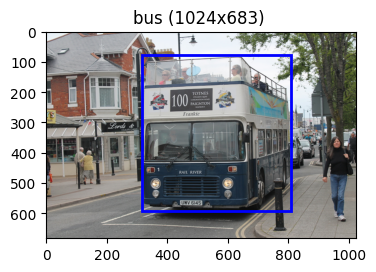

In [6]:
d, i = load_image(log=True)
plot_sample(d, i)
plt.show()

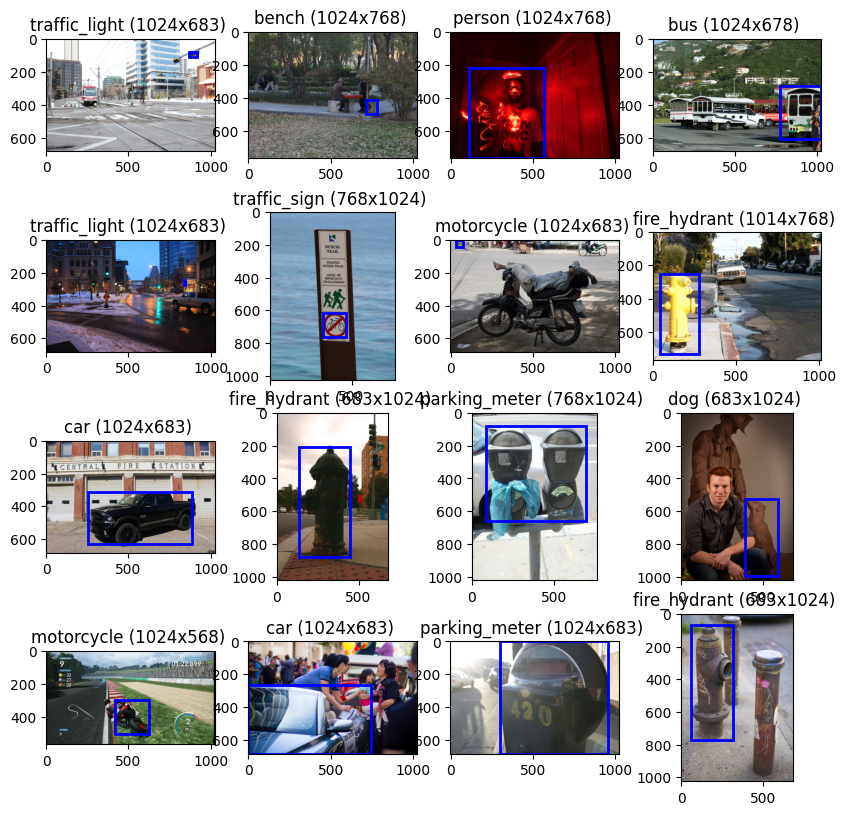

In [7]:
fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for ax in axs.flatten():
    plot_sample(*load_image(), ax)
plt.show()

Loading train/person/0006ffb07fd3f04a


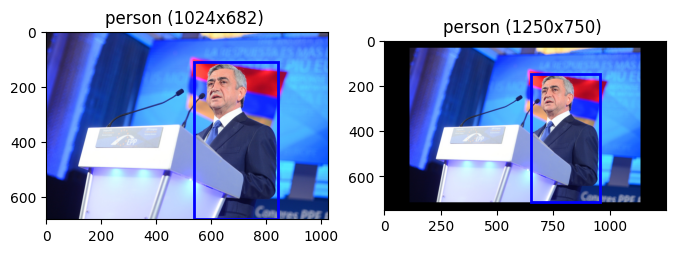

In [8]:
def pad_up_sample(descriptor, image: np.ndarray, sampling=500):
    sampling = sampling // 2
    h, w = image.shape[:2]
    hn, wn = (1 + (h - 1) // sampling) * sampling, (1 + (w - 1) // sampling) * sampling
    padded = np.zeros((hn, wn, image.shape[2]), dtype=image.dtype)
    ho, wo = (hn - h) // 2, (wn - w) // 2
    padded[ho:ho + h, wo:wo + w, :] = image
    descriptor, box = descriptor.copy(), descriptor['box']
    descriptor['box'] = (wo + box[0], ho + box[1], wo + box[2], ho + box[3])
    return descriptor, padded


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image(log=True)
plot_sample(d, i, ax=axs[0])
plot_sample(*pad_up_sample(d, i), ax=axs[1])
plt.show()

Loading train/truck/01390b86c3dfd155


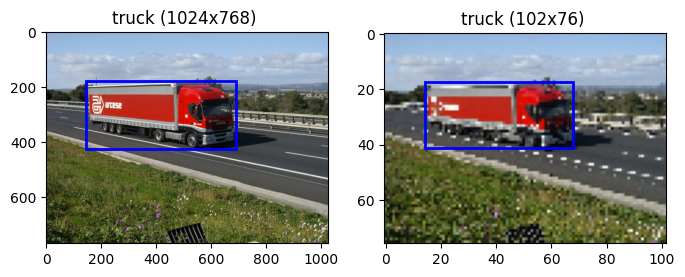

In [9]:
def rescale_sample(descriptor, image, target):
    if isinstance(target, float):
        target = (int(image.shape[0] * target), int(image.shape[1] * target))
    if isinstance(target, int):
        target = (target, int(target / image.shape[0] * image.shape[1]))
    rescaled = cv2.resize(image, dsize=target[::-1], interpolation=cv2.INTER_CUBIC)
    descriptor, box = descriptor.copy(), descriptor['box']
    descriptor['box'] = (box[0] / image.shape[1] * target[1], box[1] / image.shape[0] * target[0],
                         box[2] / image.shape[1] * target[1], box[3] / image.shape[0] * target[0])
    return descriptor, rescaled


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image(log=True)
plot_sample(d, i, ax=axs[0])
plot_sample(*rescale_sample(d, i, 0.1), ax=axs[1])
plt.show()

Loading train/dog/00785bd8accf7c05


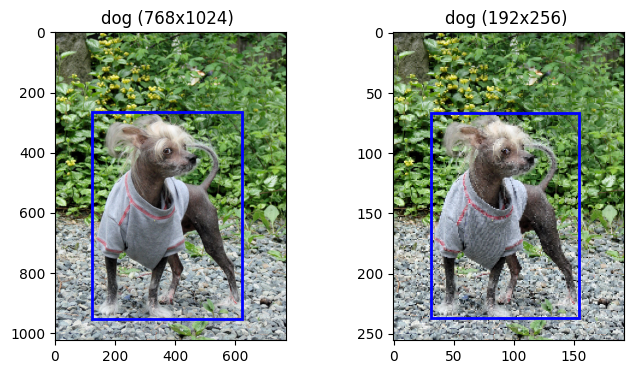

In [10]:
def ensure_within(descriptor, image, max_bounds=256):
    if image.shape[0] > image.shape[1]:
        return rescale_sample(descriptor, image, max_bounds)
    return rescale_sample(descriptor, image, int(max_bounds / image.shape[1] * image.shape[0]))


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image(log=True)
plot_sample(d, i, ax=axs[0])
plot_sample(*ensure_within(d, i), ax=axs[1])
plt.show()

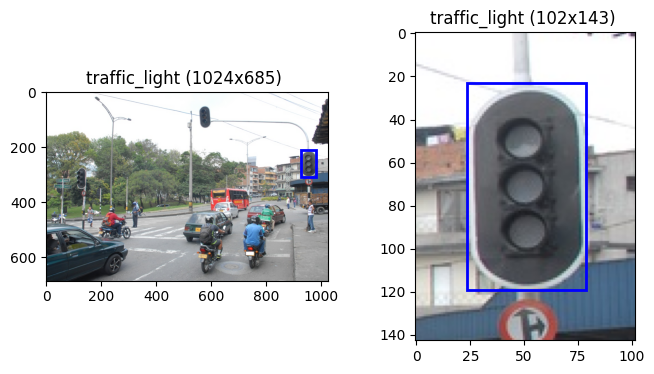

In [11]:
def context_crop_sample(descriptor, image, ratio=1.0):
    h, w = image.shape[:2]
    descriptor, box = descriptor.copy(), descriptor['box']
    major_size = (box[2] - box[0] + box[3] - box[1]) * ratio / 2
    bx1 = int(max(0, box[0] - major_size))
    bx2 = int(min(w, box[2] + major_size))
    by1 = int(max(0, box[1] - major_size))
    by2 = int(min(h, box[3] + major_size))
    cropped = image[by1:by2, bx1:bx2, :]
    descriptor['box'] = (box[0] - bx1, box[1] - by1, box[2] - bx1, box[3] - by1)
    return descriptor, cropped


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image('train', 'traffic_light', '03b7eaf956c7d0bf')
plot_sample(d, i, ax=axs[0])
plot_sample(*context_crop_sample(d, i, ratio=0.3), ax=axs[1])
plt.show()

In [12]:
def area(rect):
    return (rect[2] - rect[0]) * (rect[3] - rect[1])


def clip(x, m, M):
    return max(m, min(M, x))

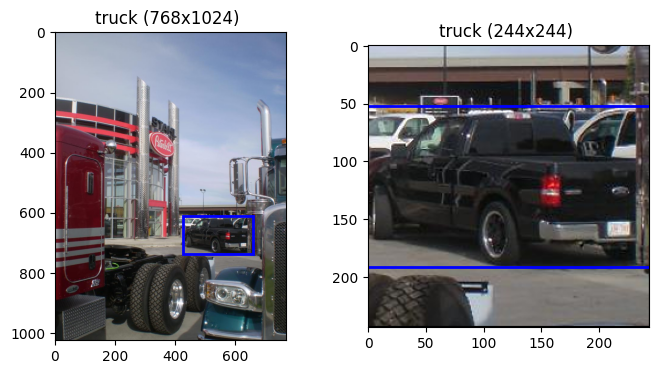

In [13]:
def split_sample(descriptor, image: np.ndarray, sampling=500, return_boxes=False):
    count = 0
    slide = sampling // 2

    h, w = image.shape[:2]
    while w >= sampling and h >= sampling:
        count += (w // slide - 1) * (h // slide - 1)
        w, h = w // 2, h // 2

    samples = np.zeros((count, 3, sampling, sampling))
    labels = np.zeros((count, 5), dtype=np.float32)

    x1, y1, x2, y2 = descriptor['box']
    original_area = area(descriptor['box'])
    is_known_label = descriptor['label'] in ["bus", "truck", "car", "bike"]
    l_desc = []

    h, w = image.shape[:2]
    c, s = 0, 1
    while w - s * sampling + 1 > 0 and h - s * sampling + 1 > 0:
        for x in range(0, w - s * sampling + 1, s * slide):
            for y in range(0, h - s * sampling + 1, s * slide):
                samples[c] = image[y:y + s * sampling:s, x:x + s * sampling:s].transpose(2, 0, 1)

                raw_box = ((x1 - x) / s, (y1 - y) / s,
                           (x2 - x) / s, (y2 - y) / s)
                box = (clip(raw_box[0], 0, sampling), clip(raw_box[1], 0, sampling),
                       clip(raw_box[2], 0, sampling), clip(raw_box[3], 0, sampling))
                # min(raw_box[0] + sampling, raw_box[2]), min(raw_box[1] + sampling, raw_box[3]))

                if is_known_label:
                    ratio = clip(max(
                        area(box) / original_area * s * s,
                        area(box) / sampling / sampling),
                        0, 1
                    )
                    # ratio = min(0, max(
                    #     area(box) / original_area, 1
                    #     # area(box) / area(raw_box),
                    # ))
                    labels[c, class_to_idx[descriptor['label']]] = ratio
                    labels[c, class_to_idx['none']] = 1 - ratio
                else:
                    labels[c, class_to_idx['none']] = 1

                if return_boxes:
                    desc = descriptor.copy()
                    desc['box'] = box
                    l_desc.append(desc)
                c += 1
                if c == 102:
                    continue
        s = s * 2

    return labels, samples, l_desc


def process_sample(descriptor, image, return_boxes=False):
    descriptor, image = context_crop_sample(descriptor, image, ratio=0.6)
    descriptor, image = ensure_within(descriptor, image, max_bounds=256)
    descriptor, image = pad_up_sample(descriptor, image, sampling=32)
    labels, samples, descriptors = split_sample(descriptor, image, sampling=32, return_boxes=return_boxes)
    return labels, samples, descriptors, descriptor, image


def center_crop_sample(descriptor: Descriptor, image: np.ndarray, ratio=1.0):
    """
    Crop away areas too far from the main item of the image, as described by the descriptor.
    """
    h, w = image.shape[:2]
    descriptor, box = descriptor.copy(), descriptor['box']
    center = (box[0] + box[2]) / 2, (box[1] + box[3]) / 2
    major_size = (box[2] - box[0] + box[3] - box[1]) * ratio / 2
    bx1 = int(max(0., center[0] - major_size))
    bx2 = int(min(w, center[0] + major_size))
    by1 = int(max(0., center[1] - major_size))
    by2 = int(min(h, center[1] + major_size))
    cropped = image[by1:by2, bx1:bx2, :]
    descriptor['box'] = (box[0] - bx1, box[1] - by1, box[2] - bx1, box[3] - by1)
    return descriptor, cropped
def process_sample_v2(descriptor, image, *args):
    descriptor, image = center_crop_sample(descriptor, image, ratio=0.6)  # Very focussed
    descriptor, image = ensure_within(descriptor, image, max_bounds=244)  # For mobile net
    descriptor, image = pad_up_sample(descriptor, image, sampling=244 * 2)  # For mobile net
    labels = np.zeros((1, 2), dtype=np.int64)
    labels[0, 0] = 1 # is known or not
    labels[0, 1] = class_to_idx[descriptor['label']]
    return labels, [image.transpose(2, 0, 1)], None, descriptor, image




_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image('train', 'truck', '0e8a8d1dc876b6a6')
plot_sample(d, i, ax=axs[0])
l, s, ld, d, i = process_sample_v2(d, i)
plot_sample(d, i, ax=axs[1])
plt.show()

In [14]:
s.shape

AttributeError: 'list' object has no attribute 'shape'

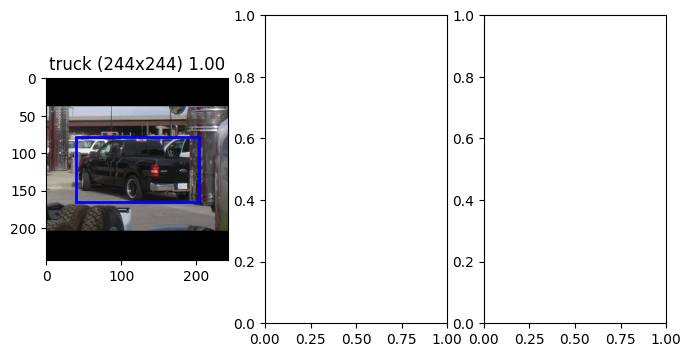

In [19]:
_, axs = plt.subplots(1, 3, figsize=(8, 4))
plot_sample(ld[0], s[0].transpose(1, 2, 0).astype(np.uint8), ax=axs[0], addon=f'{l[0][1]:.2f}')
# plot_sample(ld[197], s[197].transpose(1, 2, 0).astype(np.uint8), ax=axs[1], addon=f'{l[197][1]:.2f}')
# plot_sample(ld[218], s[218].transpose(1, 2, 0).astype(np.uint8), ax=axs[2], addon=f'{l[218][1]:.2f}')
plt.show()

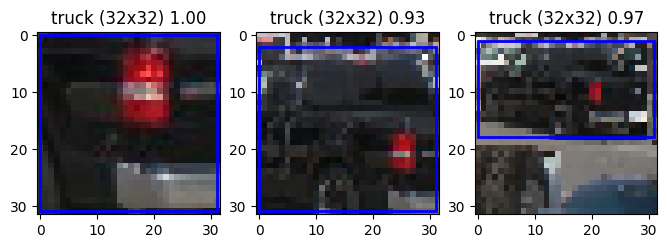

In [16]:
_, axs = plt.subplots(1, 3, figsize=(8, 4))
plot_sample(ld[102], s[102].transpose(1, 2, 0).astype(np.uint8), ax=axs[0], addon=f'{l[102][1]:.2f}')
plot_sample(ld[197], s[197].transpose(1, 2, 0).astype(np.uint8), ax=axs[1], addon=f'{l[197][1]:.2f}')
plot_sample(ld[218], s[218].transpose(1, 2, 0).astype(np.uint8), ax=axs[2], addon=f'{l[218][1]:.2f}')
plt.show()

In [16]:
""

''

In [25]:
from torch.utils.data._utils.collate import default_collate


def collate_fn(batch):
    if len(batch) == 1:
        return batch[0][0], batch[0][1]

    descriptors = [item[0] for item in batch]
    images = [item[1] for item in batch]

    images = default_collate(images)

    return descriptors, images


class PipelinedDataset(IterableDataset):
    def __init__(self, dir_dataset: DirDataset, innate_batch=16, buffer_size=512):
        self.loader = DataLoader(dir_dataset, collate_fn=collate_fn)
        self.innate_batch = innate_batch
        self.buf_desc = np.zeros((innate_batch, 5), dtype=np.float32)
        self.buf_img = np.zeros((innate_batch, 3, 32, 32), dtype=np.uint8)
        assert buffer_size % innate_batch == 0

    def flush_buffer(self):
        perm = np.random.permutation(len(self.buf_img))
        # descs = [self.buf_desc[i] for i in perm]
        descs = self.buf_desc[perm]
        imgs = self.buf_img[perm]

        for st in range(0, self.buf_img.shape[0], self.innate_batch):
            yield imgs[st:st + self.innate_batch], descs[st:st + self.innate_batch]

        self.buf_img.fill(0)

    def push_buffer(self, offset, labels, samples):
        if len(samples) + offset[0] > len(self.buf_img):

            fill_descs = labels[:len(self.buf_img) - offset[0]]
            fill_imgs = samples[:len(self.buf_img) - offset[0]]
            next_descs = labels[len(self.buf_img) - offset[0]:]
            next_imgs = samples[len(self.buf_img) - offset[0]:]

            self.buf_desc[offset[0]:] = fill_descs
            self.buf_img[offset[0]:] = fill_imgs
            for x in self.flush_buffer(): yield x

            offset[0] = 0
            yield from self.push_buffer(offset, next_descs, next_imgs)
            return

        self.buf_desc[offset[0]:offset[0] + len(labels)] = labels
        self.buf_img[offset[0]:offset[0] + len(samples)] = samples

        if offset[0] == len(self.buf_img):
            for x in self.flush_buffer(): yield x
            offset[0] = 0
            return

        offset[0] = offset + len(samples)

    def __iter__(self):
        offset = [0]
        for descriptor, image in self.loader:
            labels, samples, *_ = process_sample(descriptor, image)
            # yield from self.push_buffer(offset, labels, samples)
            for label, sample in zip(labels, samples):
                yield sample, label


dir_dataset = DirDataset(hard_limit=10)
pipe_dataset = PipelinedDataset(dir_dataset)
loadder = DataLoader(pipe_dataset, batch_size=16)





In [26]:
c = 0
for x in loadder:
    print(type(x))
    print(len(x))
    print(type(x[0]))
    print(x[0].shape)
    print(type(x[1]))
    print(x[1].shape)
    if c == 0: break
    c = c + 1

<class 'list'>
2
<class 'torch.Tensor'>
torch.Size([16, 3, 32, 32])
<class 'torch.Tensor'>
torch.Size([16, 5])


In [18]:
c = 0
for x in pipe_dataset.loader:
    print(len(x))
    print(x[0])
    print(x[1].shape)
    if c == 3: break
    c = c + 1

batch [({'label': 'truck', 'box': (427.52, 408.47562, 550.4, 526.28058), 'dir': ('train', 'truck', '19d0f6a46d5d66eb')}, array([[[136, 159, 151],
        [139, 162, 154],
        [142, 165, 157],
        ...,
        [ 43,  80,   0],
        [ 51,  88,   8],
        [ 70, 104,  27]],

       [[137, 160, 152],
        [139, 162, 154],
        [141, 164, 156],
        ...,
        [ 53,  90,  12],
        [ 58,  92,  15],
        [ 65,  99,  23]],

       [[139, 162, 152],
        [139, 162, 152],
        [140, 163, 155],
        ...,
        [ 59,  96,  18],
        [ 61,  95,  19],
        [ 62,  96,  20]],

       ...,

       [[ 54,  60,  58],
        [ 50,  59,  56],
        [ 59,  71,  67],
        ...,
        [188, 185, 170],
        [186, 183, 168],
        [185, 182, 167]],

       [[ 52,  58,  56],
        [ 47,  56,  53],
        [ 56,  68,  66],
        ...,
        [187, 184, 169],
        [187, 184, 169],
        [187, 184, 169]],

       [[ 51,  55,  54],
        [ 48,  5

AttributeError: 'list' object has no attribute 'shape'